In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#import h5py

In [2]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7333557/neutron_transferfunction_planarsource_scintillator_00.root")
tree = file["Primary"]
tree2 = file["WaterNeutrons"]
tree3 = file["AirNeutrons"]
tree4 = file["DetectorNeutrons"]
tree5 = file["Hits"]

df = tree.arrays(library="pd")
#df2 = tree2.arrays(library="pd")
#df3 = tree3.arrays(library="pd")
df4 = tree4.arrays(library="pd")
df5 = tree5.arrays(library="pd")

#df['ParticleName'] = df['ParticleName'].astype(str)


In [3]:

print(df)
print(df4)

merged_df4 = df.merge(df4, on=["EventID"], how="inner")
print(merged_df4)

merged_df5 = merged_df4.merge(df5, on=["EventID"], how="inner")
print(merged_df5)

merged_df5["ParticleName"] = merged_df5["ParticleName"].astype(str)

         EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  PrimaryPosY  \
0            0.0      1.0   2112.0     183.793718       -510.0   -33.337158   
1            1.0      1.0   2112.0     190.572366       -510.0  -396.683088   
2            2.0      1.0   2112.0      16.582414       -510.0   342.390472   
3            3.0      1.0   2112.0      27.201666       -510.0   311.401465   
4            4.0      1.0   2112.0     154.828594       -510.0   368.364570   
...          ...      ...      ...            ...          ...          ...   
999995  999995.0      1.0   2112.0     172.260769       -510.0  -440.183994   
999996  999996.0      1.0   2112.0     188.893039       -510.0  -258.332105   
999997  999997.0      1.0   2112.0       5.004282       -510.0   -65.029359   
999998  999998.0      1.0   2112.0      54.765591       -510.0   127.520279   
999999  999999.0      1.0   2112.0     144.420673       -510.0    94.611775   

        PrimaryPosZ  PrimaryMomentumX  PrimaryMomen

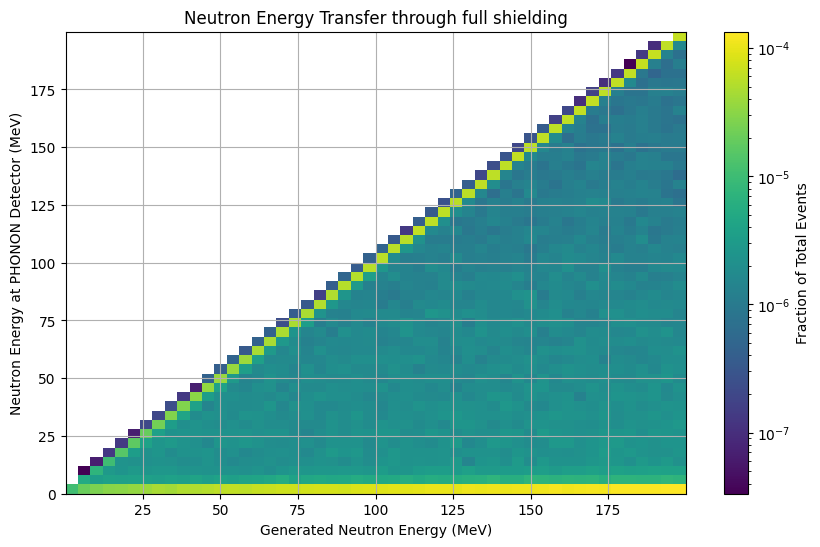

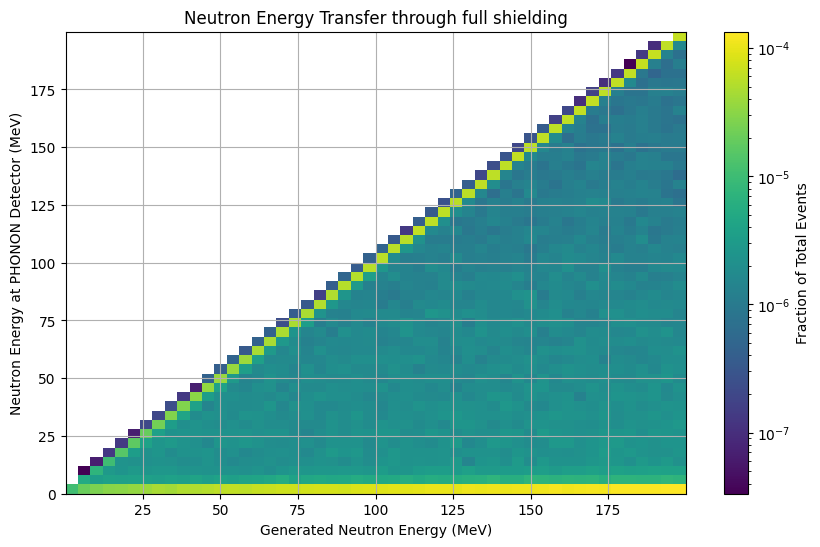

In [5]:
from matplotlib.colors import LogNorm
'''
heatmap, xedges, yedges = np.histogram2d(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through lead shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at lead/water shield boundary')
plt.grid()
plt.savefig("NeutronTransfer_LeadWaterBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through water shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.savefig("NeutronTransfer_WaterFridgeBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill3['KineticEnergy_x'], merged_df_fill3['KineticEnergy_y'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function between shielding layers')
plt.xlabel('Neutron Energy at lead/water shield boundary')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.show()
'''
#prim_mask = (merged_df4['TrackID_y'] == 1)

#prim_merged_df4 = merged_df4[prim_mask]

heatmap, xedges, yedges = np.histogram2d(merged_df4['PrimaryEnergy_x'], merged_df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'])
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
plt.savefig("NeutronTransfer_FullScintillator_planarneutrons_FracColorBar.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'])
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
#plt.savefig("NeutronTransfer_FridgeDetectorBoundary_SavePrimariesOnly_planarneutrons_FracColorBar.pdf")
plt.show()


[20024 19986 20150 20213 19876 19857 19880 20057 20211 20034 19947 19867
 19668 19814 19999 19967 20057 19847 19922 20022 20030 20037 19754 20067
 20285 20071 19929 20100 20081 20031 19854 20001 19944 20189 19935 19948
 19932 20164 20167 20012 20118 20002 20103 20078 20032 19869 19996 20002
 19932 19939]
[3.49618489e-04 4.00034173e+00 8.00033383e+00 1.20003259e+01
 1.60003180e+01 2.00003102e+01 2.40003023e+01 2.80002944e+01
 3.20002865e+01 3.60002786e+01 4.00002707e+01 4.40002628e+01
 4.80002549e+01 5.20002470e+01 5.60002391e+01 6.00002312e+01
 6.40002233e+01 6.80002154e+01 7.20002075e+01 7.60001996e+01
 8.00001918e+01 8.40001839e+01 8.80001760e+01 9.20001681e+01
 9.60001602e+01 1.00000152e+02 1.04000144e+02 1.08000136e+02
 1.12000129e+02 1.16000121e+02 1.20000113e+02 1.24000105e+02
 1.28000097e+02 1.32000089e+02 1.36000081e+02 1.40000073e+02
 1.44000065e+02 1.48000058e+02 1.52000050e+02 1.56000042e+02
 1.60000034e+02 1.64000026e+02 1.68000018e+02 1.72000010e+02
 1.76000002e+02 1.79999

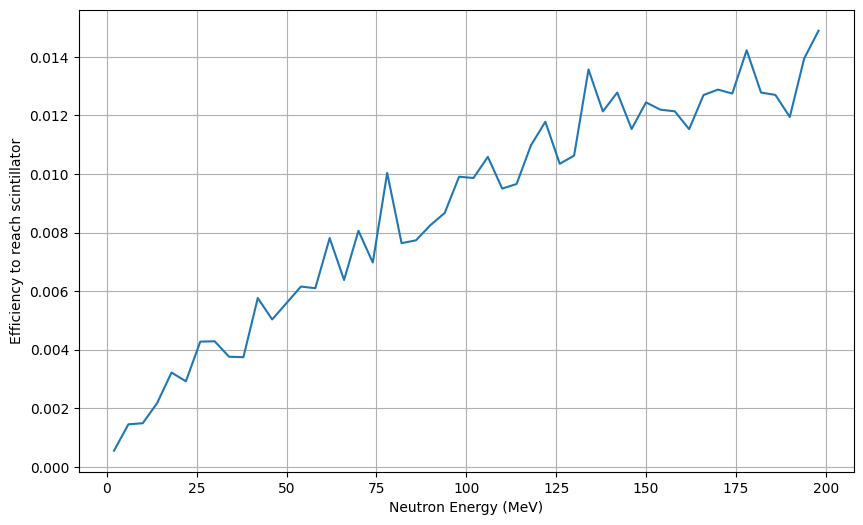

In [17]:
#generate binning in same way as above plot for primary energy to setup looking for hits in the scintillator 
#do for both overall neutrons and neutrons that enter the detector
#Look for both hits in 0-150 keV individually and also total NR for LiNbO3 block events
bins_num = 50
Emin, Emax = df['PrimaryEnergy'].min(), df['PrimaryEnergy'].max()
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(counts_den)
print(edges)

bin_centers = (edges[:-1] + edges[1:]) / 2.0

new_counts, _ = np.histogram(df4['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts, counts_den)
print(eff_vals)

plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to reach scintillator")
plt.grid()
plt.savefig("test_efficiency_scintillator.pdf")
plt.show()




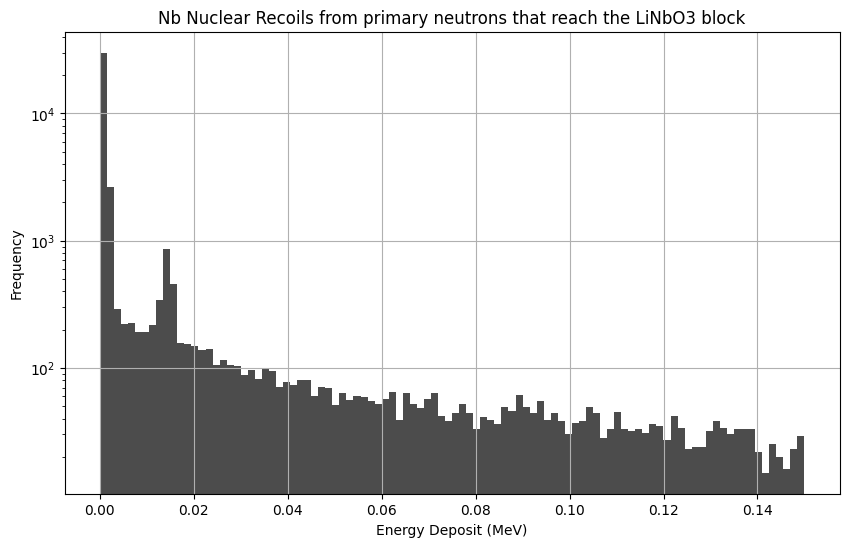

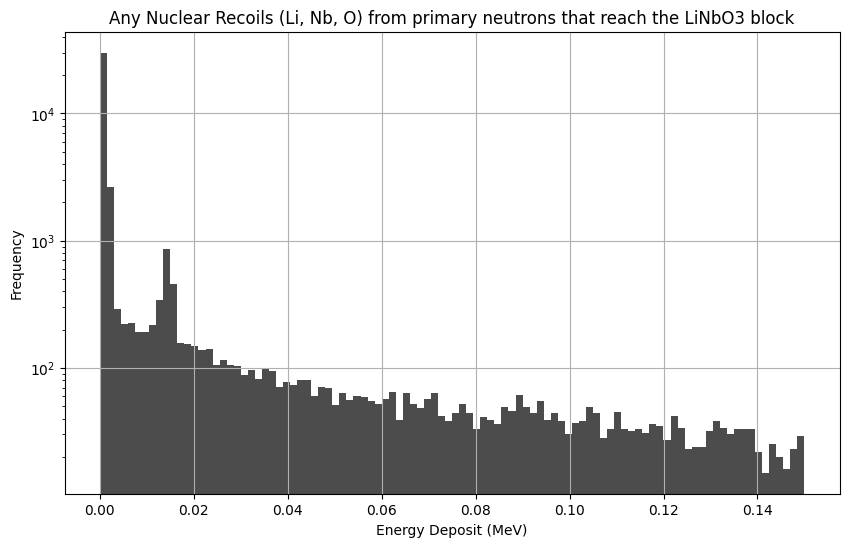

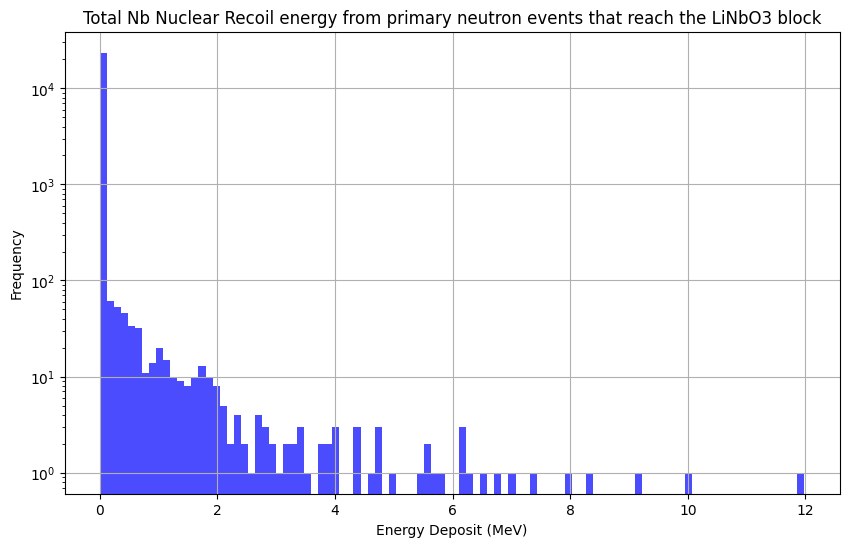

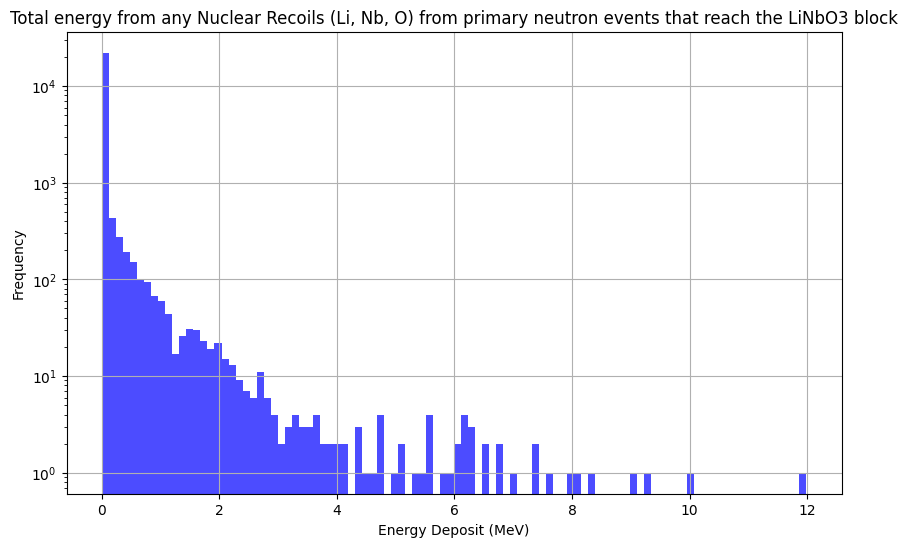

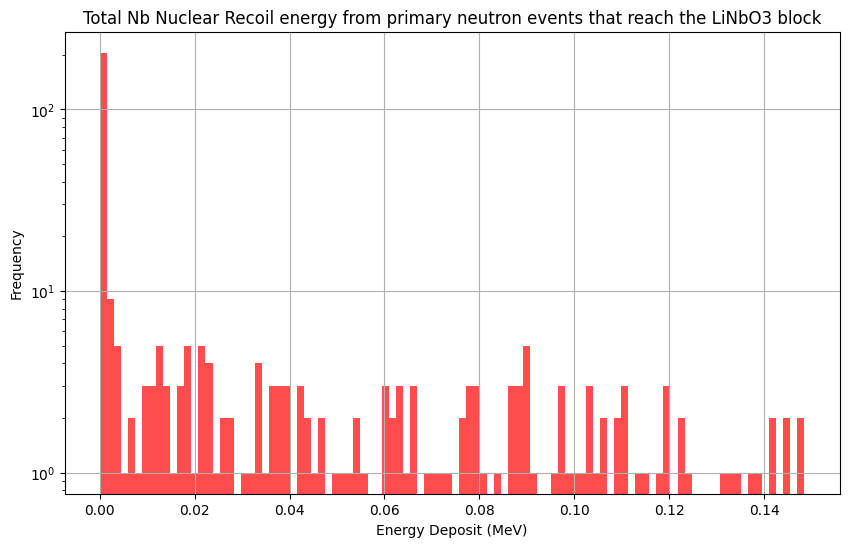

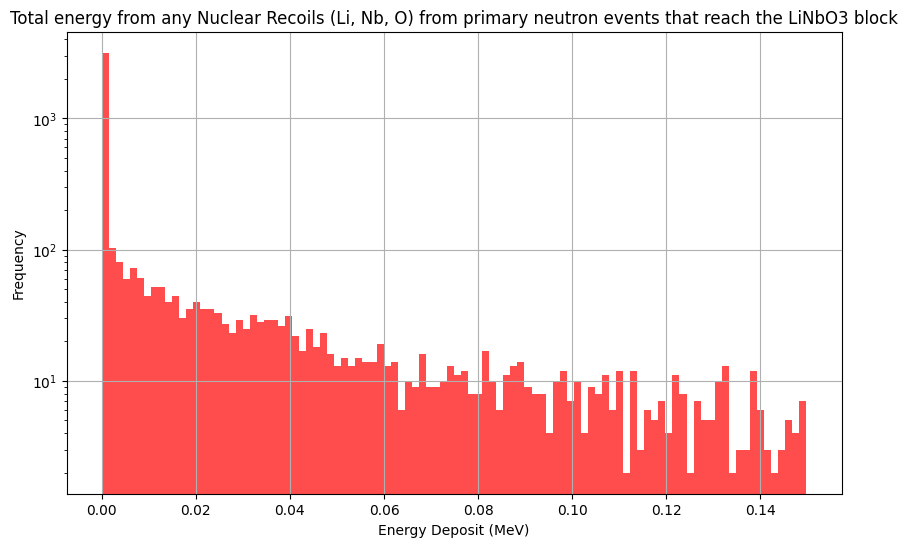

In [ ]:
#example from another notebook to plot nuclear recoils in LiNbO3 from neutrons, could do similar for scintillator

mask_nb = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False)
mask_nr = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False) | merged_df5["ParticleName"].str.contains('Li', case=False, na=False) | merged_df5["ParticleName"].str.contains('O', case=False, na=False)
nb_recoil_df = merged_df5[mask_nb]
nr_recoil_df = merged_df5[mask_nr]

mask_nb_roi = merged_df5["Edep"] < 0.15

nb_roi_df = merged_df5[mask_nb_roi]
nr_roi_df = merged_df5[mask_nb_roi]

plt.figure(figsize=(10,6))
plt.hist(nb_roi_df['Edep'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoil_hitlevelNb_planarneutrons.pdf")
plt.show()



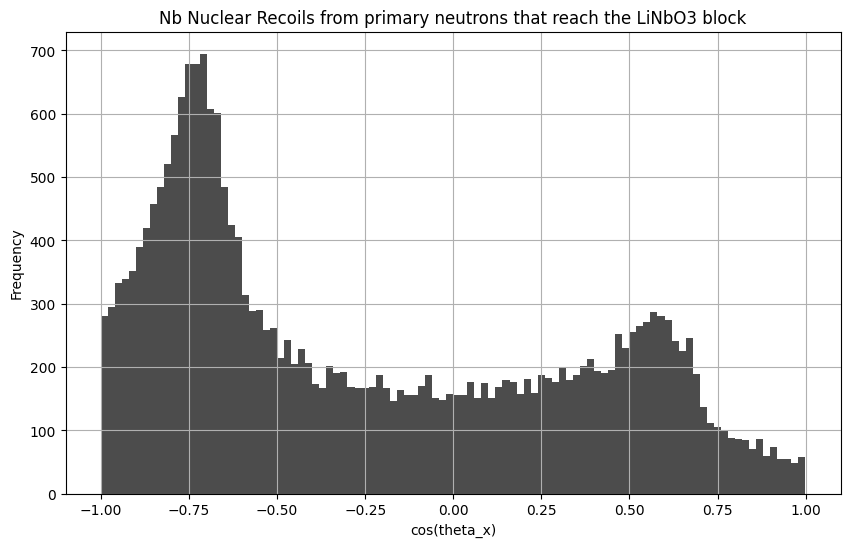

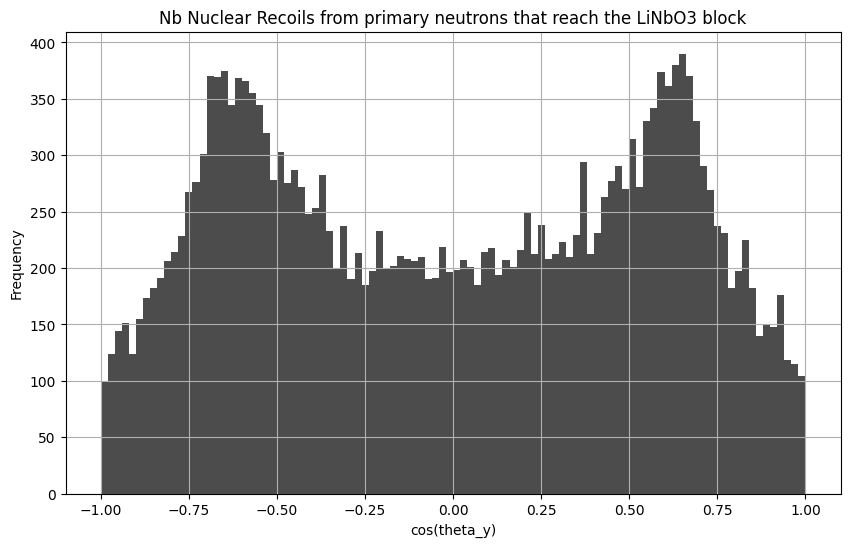

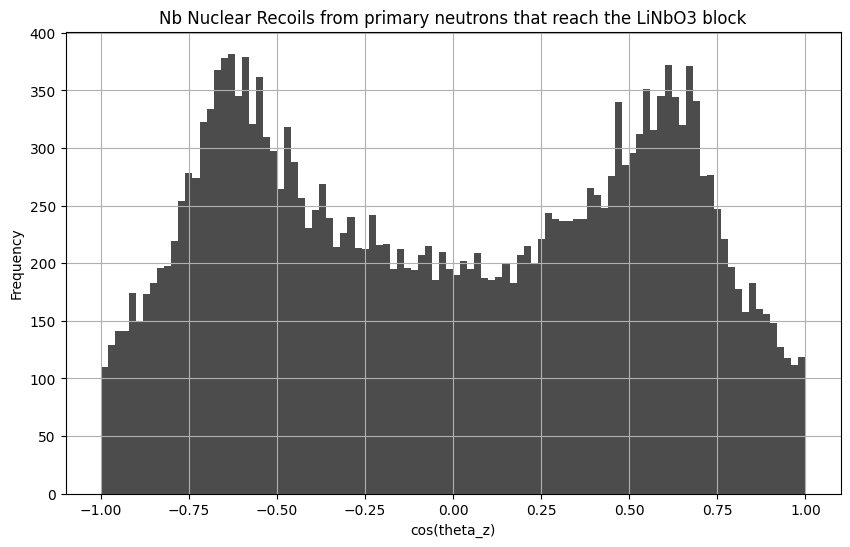